In [ ]:
!pip install transformers --upgrade -q
!pip install scikit-learn xgboost shap imbalanced-learn --upgrade -q

In [ ]:
import kagglehub
path = kagglehub.dataset_download("wordsforthewise/lending-club")

print("Path to dataset files:", path)

100%|██████████| 1.26G/1.26G [00:22<00:00, 59.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/wordsforthewise/lending-club/versions/3


In [ ]:
import pandas as pd
import os

# Direct path to the EXACT file
file_path = os.path.join(path, 'accepted_2007_to_2018Q4.csv.gz')

# Load it (it's gzipped so specify compression)
# Load full dataset but sample across all years
df = pd.read_csv(file_path, compression='gzip', low_memory=False)

# Sample 100k randomly across all years
df = df.sample(n=100000, random_state=42)

print(f" Loaded: {df.shape}")

 Loaded: (100000, 151)


In [ ]:
df.columns

Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
       'disbursement_method', 'debt_settlement_flag',
       'debt_settlement_flag_date', 'settlement_status', 'settlement_date',
       'settlement_amount', 'settlement_percentage', 'settlement_term'],
      dtype='object', length=151)

In [ ]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
392949,39651438,NaN,32000.0,32000.0,32000.0,60 months,10.49,687.65,B,B3,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1273506,16411620,NaN,9600.0,9600.0,9600.0,36 months,12.99,323.42,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
324024,45122316,NaN,4000.0,4000.0,4000.0,36 months,6.68,122.93,A,A3,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2066630,125356772,NaN,6025.0,6025.0,6025.0,36 months,10.91,197.00,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
477199,128490686,NaN,25000.0,25000.0,25000.0,60 months,26.30,752.96,E,E5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
th = 0.8
missing_values = df.isna().sum() / len(df)
cols = missing_values[missing_values > th].index
df_clean = df.drop(columns = cols)
df_clean

,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,...,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag
392949,39651438,32000.0,32000.0,32000.0,60 months,10.49,687.65,B,B3,Public Service,...,28.6,0.0,0.0,556496.0,103647.0,64100.0,72197.0,N,Cash,N
1273506,16411620,9600.0,9600.0,9600.0,36 months,12.99,323.42,C,C1,NaN,...,50.0,1.0,0.0,11600.0,4509.0,2400.0,0.0,N,Cash,N
324024,45122316,4000.0,4000.0,4000.0,36 months,6.68,122.93,A,A3,System Analyst,...,0.0,0.0,0.0,222616.0,64253.0,5600.0,76154.0,N,Cash,N
2066630,125356772,6025.0,6025.0,6025.0,36 months,10.91,197.00,B,B4,Admin assistant,...,0.0,0.0,0.0,32227.0,5559.0,11000.0,11127.0,N,Cash,N
477199,128490686,25000.0,25000.0,25000.0,60 months,26.30,752.96,E,E5,Coordinator,...,10.0,0.0,0.0,257219.0,97647.0,179400.0,65719.0,N,Cash,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
575559,117031217,22000.0,22000.0,22000.0,36 months,5.32,662.53,A,A1,owner,...,0.0,0.0,0.0,238190.0,22437.0,37200.0,18384.0,N,Cash,N
363389,41368988,25200.0,25200.0,25200.0,36 months,16.99,898.33,D,D3,CEO,...,33.3,0.0,0.0,213047.0,117246.0,127800.0,66047.0,N,Cash,N
1908460,1513211,10000.0,10000.0,10000.0,36 months,15.31,348.18,C,C2,Austin Independent School District,...,50.0,0.0,0.0,204414.0,64269.0,3400.0,66656.0,N,Cash,N
1487889,135125990,20000.0,20000.0,20000.0,36 months,14.52,688.62,C,C3,Manager,...,100.0,1.0,0.0,40979.0,23867.0,9300.0,18479.0,N,Cash,N


In [ ]:
df_clean.shape

(100000, 112)

In [ ]:
df_clean['loan_status'].unique()

array(['Current', 'Fully Paid', 'Charged Off', 'Late (31-120 days)',
       'Late (16-30 days)', 'In Grace Period',
       'Does not meet the credit policy. Status:Fully Paid',
       'Does not meet the credit policy. Status:Charged Off', nan],
      dtype=object)

In [ ]:
df_clean = df_clean[df_clean['loan_status'].isin(['Fully Paid','Charged Off'])]
df_clean['target']=(df_clean['loan_status']== 'Charged Off').astype(int)
print((df_clean['target'] ==1).sum())
print(df_clean['target'].mean()*100)
print(df_clean['target'].head(50))
df_clean['target']

12034
20.227249806703195
1273506    0
324024     0
2066630    0
1975547    0
302723     0
1972188    0
2251549    0
641990     0
394636     0
1198110    0
710850     0
1987097    0
367120     1
273432     0
1839550    0
1781031    1
1882235    0
643490     0
1230912    1
597495     0
101648     0
2030234    0
2237373    0
195947     0
185915     1
159697     0
150402     0
1786592    0
1665654    1
453731     0
1151106    0
185114     0
271414     1
1656654    0
630035     1
294617     0
1618026    0
1658991    0
1862850    0
1155210    0
746136     1
294745     0
2247603    0
2256118    0
1999471    0
391319     0
306938     0
1328234    0
1856372    1
219428     0
Name: target, dtype: int64


/tmp/ipykernel_47748/1938325470.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['target']=(df_clean['loan_status']== 'Charged Off').astype(int)


,target
1273506,0
324024,0
2066630,0
1975547,0
302723,0
...,...
1217099,0
32451,0
363389,0
1908460,0


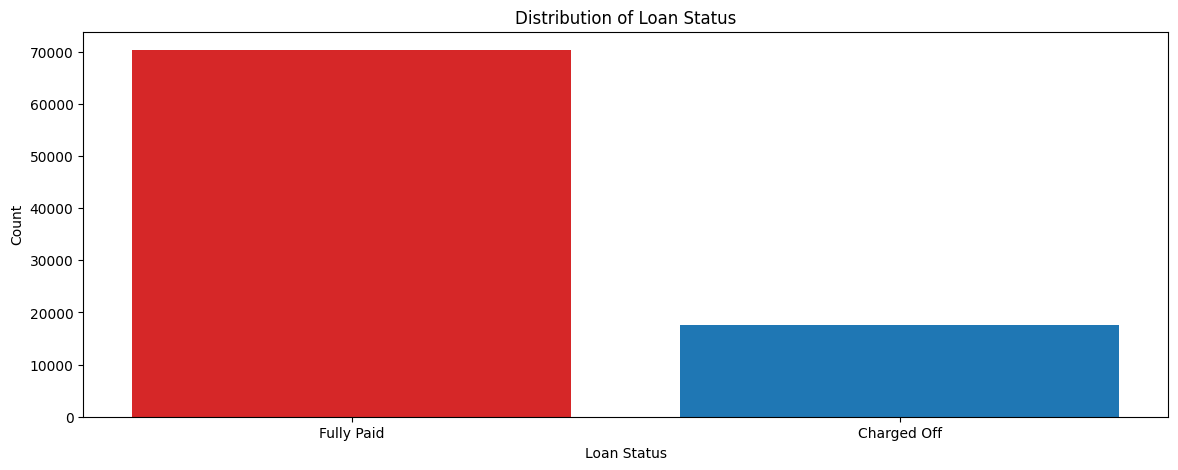

In [ ]:
import matplotlib.pyplot as plt

target_counts = df_clean['target'].value_counts()
fig, ax = plt.subplots(figsize=(14, 5))
bar_colors = ['tab:red', 'tab:blue']
ax.bar(['Fully Paid', 'Charged Off'], target_counts, color=bar_colors)
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.title('Distribution of Loan Status')
plt.show()

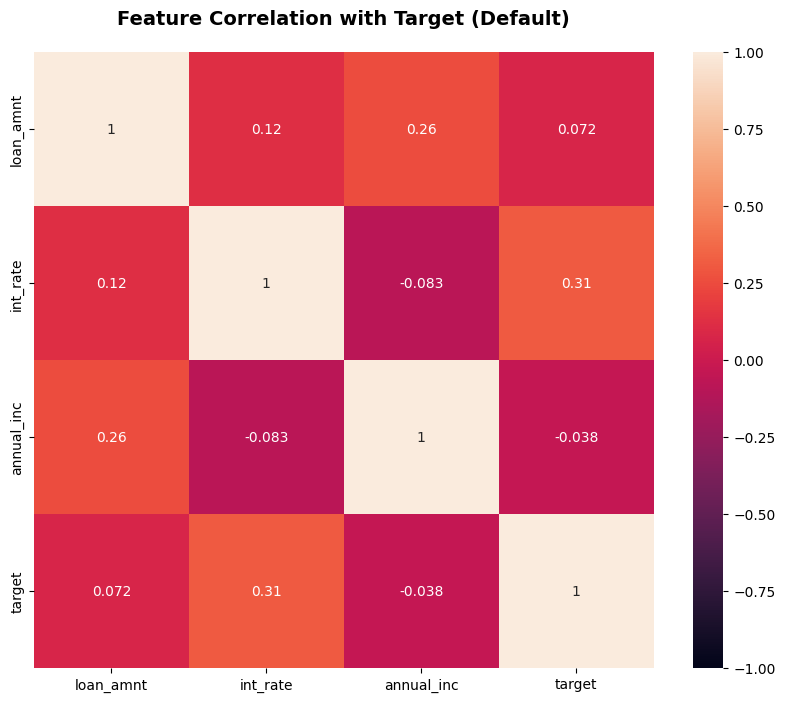

In [ ]:
import seaborn as sns
cols = ['loan_amnt', 'int_rate', 'annual_inc', 'target']
corr_matrix = df_clean[cols].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True,vmin=-1, vmax=1)
ax.set_title('Feature Correlation with Target (Default)', fontsize=14, fontweight='bold', pad=20)
plt.show()

In [ ]:
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

text_columns = ['emp_title', 'title', 'desc', 'purpose']
existing_text_cols = [col for col in text_columns if col in df_clean.columns]
print(f"Available text columns:")
for col in existing_text_cols:
    non_null = df_clean[col].notna().sum()
    pct = non_null / len(df_clean) * 100
    print(f"   • {col}: {non_null:,} non-null ({pct:.1f}%)")

# Text cleaning function
def clean_text(text):
  text = str(text).lower()
  text = re.sub(r'http\S+', '', text)
  text = re.sub(r'[^a-zA-Z\s]', ' ', text)
  text = re.sub(r'\s+', ' ', text)
  text = text.strip()

  return text

print(" Cleaning and combining text")

df_clean['combined_text'] = ''
for col in existing_text_cols:
    print(f"   Processing {col}...")
    df_clean['combined_text'] += df_clean[col].apply(clean_text) + ' '

df_clean['combined_text'] = df_clean['combined_text'].str.strip()

min_text_length = 10
df_clean = df_clean[df_clean['combined_text'].str.len() >= min_text_length].copy()

print("Text processing complete")
print(f" Rows with sufficient text: {len(df_clean):,}")
print(f" Average text length: {df_clean['combined_text'].str.len().mean():.0f} characters")
print(f" Sample text:")
print(f"'{df_clean['combined_text'].iloc[0][:150]}...'")

# ============================================================================
# STEP 4: NUMERICAL FEATURES
# ============================================================================

print("\n🔢 STEP 4: Numerical Feature Selection")
print("-"*70)

# Select numerical columns
numerical_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove IDs and target
exclude_cols = ['id', 'member_id', 'target', 'policy_code','recoveries', 'collection_recovery_fee', 'total_rec_late_fee',
    'last_pymnt_amnt', 'last_pymnt_d', 'out_prncp', 'out_prncp_inv',
    'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int','loan_status','last_fico_range_low','last_fico_range_high']
numerical_cols = [col for col in numerical_cols if col not in exclude_cols]

# Remove columns with too many NaNs
numerical_cols = [col for col in numerical_cols
                  if df_clean[col].notna().sum() / len(df_clean) > 0.5]

print(f" Selected {len(numerical_cols)} numerical features")
print(f"   Examples: {numerical_cols[:10]}")

# Handle missing values in numerical columns (fill with median)
print(f" Handling missing values...")
for col in numerical_cols:
    if df_clean[col].isna().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)


Available text columns:
   • emp_title: 55,660 non-null (93.6%)
   • title: 58,771 non-null (98.8%)
   • purpose: 59,494 non-null (100.0%)
 Cleaning and combining text
   Processing emp_title...


/tmp/ipykernel_47748/2854937077.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['combined_text'] = ''
/tmp/ipykernel_47748/2854937077.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['combined_text'] += df_clean[col].apply(clean_text) + ' '


   Processing title...
   Processing purpose...


/tmp/ipykernel_47748/2854937077.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['combined_text'] = df_clean['combined_text'].str.strip()


Text processing complete
 Rows with sufficient text: 59,494
 Average text length: 49 characters
 Sample text:
'nan debt consolidation debt consolidation...'

🔢 STEP 4: Numerical Feature Selection
----------------------------------------------------------------------
 Selected 56 numerical features
   Examples: ['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high']
 Handling missing values...


/tmp/ipykernel_47748/2854937077.py:69: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(median_val, inplace=True)


In [ ]:
import numpy as np
out_cols = []
for cols in numerical_cols :
  # Calculate lower and upper bounds using quantiles of the column data
  lower = np.quantile(df_clean[cols], 0.01)
  upper = np.quantile(df_clean[cols], 0.99)
  # Count outliers: values below the lower bound or above the upper bound
  # Use parentheses for correct boolean Series operations
  outliers = len(df_clean[(df_clean[cols] < lower) | (df_clean[cols] > upper)])
  if outliers > 0 :
    out_cols.append(cols)
for col in out_cols :
  lower = df_clean[col].quantile(0.01)
  upper = df_clean[col].quantile(0.99)
  df_clean[col] = df_clean[col].clip(lower, upper)


In [ ]:
df_clean['issue_d'].sort_values(ascending = False)


,issue_d
768053,Sep-2018
784628,Sep-2018
776278,Sep-2018
768206,Sep-2018
761257,Sep-2018
...,...
1650746,Apr-2008
1650776,Apr-2008
1650841,Apr-2008
1650717,Apr-2008


In [ ]:
import pandas as pd

df_clean['issue_d'] = pd.to_datetime(df_clean['issue_d'])
split_date_dt = pd.to_datetime('2017-01-01')

train = df_clean[df_clean['issue_d'] < split_date_dt]
test = df_clean[df_clean['issue_d'] >= split_date_dt]
X_text_train = train['combined_text'].values
X_text_test = test['combined_text'].values

X_num_train = train[numerical_cols].values
X_num_test = test[numerical_cols].values
y_train = train['target'].values
y_test = test['target'].values



scaler = StandardScaler()
X_num_train_scaled = scaler.fit_transform(X_num_train)
X_num_test_scaled = scaler.transform(X_num_test)

/tmp/ipykernel_45959/4022748191.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean['issue_d'] = pd.to_datetime(df_clean['issue_d'])


In [ ]:
df_clean.to_csv('data_clean.csv',index = False)


In [ ]:
default_texts = df_clean[df_clean['target']==1]['combined_text']
non_default_texts = df_clean[df_clean['target']==0]['combined_text']

print("Sample default text:", default_texts.sample(3, random_state=42).values)
print("Sample non-default text:", non_default_texts.sample(3, random_state=42).values)

Sample default text: ['packaging tech debt consolidation debt consolidation'
 'nan debt consolidation debt consolidation'
 'radiologic technologist debt consolidation loan and only debt consolidation']
Sample non-default text: ['construction cable spicer debt consolidation debt consolidation'
 'shift supervisor credit card refinancing credit card'
 'property manager debt consolidation debt consolidation']


In [ ]:
default_counts = default_texts.value_counts().head(10)
non_default_counts = non_default_texts.value_counts().head(10)

print("Top default texts:\n", default_counts)
print("\nTop non-default texts:\n", non_default_counts)


Top default texts:
 combined_text
debt consolidation    10834
credit card            3609
home improvement       1000
major purchase          338
small business          234
renewable energy         11
Name: count, dtype: int64

Top non-default texts:
 combined_text
debt consolidation    38810
credit card           18421
home improvement       4586
major purchase         1427
small business          545
renewable energy         43
Name: count, dtype: int64


In [ ]:
import numpy as np

for col in df_clean.select_dtypes(include=['int64','float64']):
    corr = np.corrcoef(df_clean[col], df_clean['target'])[0,1]
    if abs(corr) > 0.8:
        print(col, corr)

target 1.0


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [ ]:
leakage_cols = [
    'recoveries', 'collection_recovery_fee', 'total_rec_late_fee',
    'last_pymnt_amnt', 'last_pymnt_d', 'out_prncp', 'out_prncp_inv',
    'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int','loan_status']
k = []
for i in leakage_cols :
  if i in numerical_cols  :
    k.append(i)
print(k)

[]


In [ ]:
import torch
import numpy as np
from transformers import BertTokenizer, BertModel

class BertEmbedding():
  def __init__(self, max_length=128):
    self.tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
    self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {self.device}")
    self.model = BertModel.from_pretrained('bert-base-uncased').to(self.device)
    self.max_length = max_length

  def embeddings(self, text, batch_size=32):
    embedding_tensors = [] # Collect PyTorch tensors
    for i in range(0, len(text), batch_size):
      batch = text[i:i+batch_size].tolist() # Ensure tokenizer receives a list of strings

      input_tokens = self.tokenizer(
          batch,
          return_tensors='pt',
          padding=True,
          truncation=True,
          max_length=self.max_length
      )

      input_tokens = {k: v.to(self.device) for k, v in input_tokens.items()}

      with torch.no_grad():
          output = self.model(**input_tokens).last_hidden_state[:,0,:]
      embedding_tensors.append(output)



    return torch.cat(embedding_tensors, dim=0)

bert = BertEmbedding(max_length = 128)
x_train_bert = bert.embeddings(X_text_train, batch_size=32)
x_test_bert = bert.embeddings(X_text_test, batch_size=32)

# Concatenate numerical and BERT embeddings.
# Move BERT embeddings to CPU and convert to NumPy before concatenating with NumPy arrays.
X_train_bert_combined = np.concatenate([X_num_train_scaled, x_train_bert.cpu().numpy()], axis=1)
X_test_bert_combined = np.concatenate([X_num_test_scaled, x_test_bert.cpu().numpy()], axis=1)
print(f"Shape of combined training data (X_train_bert_combined): {X_train_bert_combined.shape}")
print(f"Shape of combined test data (X_test_bert_combined): {X_test_bert_combined.shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Using device: cpu


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Shape of combined training data (X_train_bert_combined): (49453, 824)
Shape of combined test data (X_test_bert_combined): (10041, 824)


In [ ]:

np.save('X_train_bert_combined',X_train_bert_combined)
np.save('X_test_bert_combined',X_test_bert_combined)
np.save('y_train',y_train)
np.save('y_test',y_test)




In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(
    max_features=500,  # Top 500 words
    min_df=5,          # Word must appear in at least 5 documents
    max_df=0.8,        # Ignore words in >80% of documents
    ngram_range=(1, 2)) # Unigrams and bigrams
x_train_transform = tfidf.fit_transform(X_text_train)
x_test_transform = tfidf.transform(X_text_test)
x_train_tfidf = np.concatenate([X_num_train_scaled, x_train_transform.toarray()], axis=1)
x_test_tfidf = np.concatenate([X_num_test_scaled, x_test_transform.toarray()], axis=1)

In [ ]:
np.save('x_train_tfidf',x_train_tfidf)
np.save('x_test_tfidf',x_test_tfidf)



In [ ]:
pip install --upgrade shap


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 16.8 MB/s eta 0:00:00
  Attempting uninstall: slicer
    Found existing installation: slicer 0.0.7
    Uninstalling slicer-0.0.7:
      Successfully uninstalled slicer-0.0.7
  Attempting uninstall: shap
    Found existing installation: shap 0.42.1
    Uninstalling shap-0.42.1:
      Successfully uninstalled shap-0.42.1


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
import os

# Define the target directory
target_dir = '/content/drive/MyDrive/gg/'

# Create the directory if it doesn't exist
os.makedirs(target_dir, exist_ok=True)

files = [
    'x_train_tfidf.npy', 'x_test_tfidf.npy',
    'X_train_bert_combined.npy', 'X_test_bert_combined.npy',
    'y_train.npy', 'y_test.npy',

]
for f in files:
    shutil.copy(f, os.path.join(target_dir, f))
    print(f"Saved {f}")

KeyboardInterrupt: 

In [ ]:
!pip install mlflow dagshub optuna
import mlflow
import os
import dagshub

os.environ['MLFLOW_TRACKING_USERNAME'] = 'seif-gaaloul123'
os.environ['MLFLOW_TRACKING_PASSWORD'] = '62c4bfa157e465d4b8b0ee1d9ba84414fe6c0be2'

mlflow.set_tracking_uri('https://dagshub.com/seif-gaaloul123/credit-default-prediction.mlflow')
mlflow.set_experiment('credit-default')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 84.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 81.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 65.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.5/263.5 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

<Experiment: artifact_location='mlflow-artifacts:/e3a086ad2e5f4a878255e55916d0e504', creation_time=1773801765023, experiment_id='0', last_update_time=1773801765023, lifecycle_stage='active', name='credit-default', tags={}, workspace='default'>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import joblib
import numpy as np

x_train_tfidf = np.load('/content/drive/MyDrive/gg/x_train_tfidf.npy')
x_test_tfidf = np.load('/content/drive/MyDrive/gg/x_test_tfidf.npy')
X_train_bert_combined = np.load('/content/drive/MyDrive/gg/X_train_bert_combined.npy')
X_test_bert_combined = np.load('/content/drive/MyDrive/gg/X_test_bert_combined.npy')
y_train = np.load('/content/drive/MyDrive/gg/y_train.npy')
y_test = np.load('/content/drive/MyDrive/gg/y_test.npy')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import xgboost as xgb
import optuna
from sklearn.metrics import recall_score, roc_auc_score, confusion_matrix , precision_recall_curve , roc_curve , average_precision_score
from sklearn.model_selection import cross_val_score
import numpy as np
import matplotlib.pyplot as plt

class train_bert_tfidf():
  def __init__(self, x_train, x_text, y_train, y_test):
    self.x_train = x_train
    self.x_text = x_text
    self.y_train = y_train
    self.y_test = y_test
    self.model = None

  def tune_train_model(self):
    negative_samples = (self.y_train == 0).sum()
    positive_samples = (self.y_train == 1).sum()
    scale_pos_weight = negative_samples / positive_samples

    def objective(trial):
      params = {
                "max_depth": trial.suggest_int("max_depth", 3, 8),
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
                "n_estimators": trial.suggest_int("n_estimators", 100, 300),
                "subsample": trial.suggest_float("subsample", 0.6, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
                "min_child_weight": trial.suggest_int("min_child_weight", 1, 5),
                "scale_pos_weight": scale_pos_weight,
                "random_state": 42,
                "eval_metric": "auc",
                "objective": "binary:logistic"
            }
      xgb_model = xgb.XGBClassifier(**params)
      scores = cross_val_score(
          xgb_model,
          self.x_train,
          self.y_train,
          cv=3,
          scoring='roc_auc'
      )
      return scores.mean()

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=50, show_progress_bar=True)

    # Refit on full training data with best params
    best_params = study.best_params
    best_params['scale_pos_weight'] = scale_pos_weight
    best_params['random_state'] = 42
    best_params['eval_metric'] = 'auc'
    best_params['objective'] = 'binary:logistic'

    self.model = xgb.XGBClassifier(**best_params)
    self.model.fit(self.x_train, self.y_train)
    print(f"Best params: {study.best_params}")
    print(f"Best CV AUC: {study.best_value:.4f}")
    return self.model

  def predict(self):
    pred_proba = self.model.predict_proba(self.x_text)[:,1]
    return  pred_proba

  def evaluate(self):
    pred_proba = self.predict()

    precision, recall, thresholds = precision_recall_curve(self.y_test, pred_proba)


    scores = precision[:-1] * recall[:-1]
    threshold = thresholds[np.argmax(scores)]
    pred = (pred_proba >= threshold).astype(int)

    metrics = {
       'threshold': threshold,
       'average_precision_score' : average_precision_score(self.y_test, pred_proba),
       'recall_score': recall_score(self.y_test, pred),
       'roc_auc_score': roc_auc_score(self.y_test, pred_proba)
    }
    return metrics, pred_proba, pred

mlflow.set_experiment("credit_default_prediction")

with mlflow.start_run(run_name='xgboost_tfidf'):
    model_tfidf = train_bert_tfidf(x_train_tfidf, x_test_tfidf, y_train, y_test)
    model_tfidf.tune_train_model()
    tfidf_metrics, pred_proba, _ = model_tfidf.evaluate()
    print(f"metrics for tfidf model: {tfidf_metrics}")
    mlflow.xgboost.log_model(model_tfidf.model, "xgboost_tfidf_model")
    mlflow.log_params(model_tfidf.model.get_params())
    mlflow.log_metrics({
        'average_precision_score': tfidf_metrics['average_precision_score'],
        'recall_score':            tfidf_metrics['recall_score'],
        'roc_auc_score':           tfidf_metrics['roc_auc_score']
    })
    mlflow.log_param("optimal_threshold", tfidf_metrics['threshold'])

with mlflow.start_run(run_name='xgboost_bert'):
    model_bert = train_bert_tfidf(X_train_bert_combined, X_test_bert_combined, y_train, y_test)
    model_bert.tune_train_model()
    bert_metrics, pred_proba, _ = model_bert.evaluate()
    print(f"metrics for bert model: {bert_metrics}")
    mlflow.xgboost.log_model(model_bert.model, "xgboost_bert_model")
    mlflow.log_params(model_bert.model.get_params())
    mlflow.log_metrics({
        'average_precision_score': bert_metrics['average_precision_score'],
        'recall_score':            bert_metrics['recall_score'],
        'roc_auc_score':           bert_metrics['roc_auc_score']
    })
    mlflow.log_param("optimal_threshold", bert_metrics['threshold'])

[I 2026-03-19 12:16:43,465] A new study created in memory with name: no-name-383a4928-46c3-4ab2-bdac-75e54d8c24af


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-03-19 12:18:19,612] Trial 0 finished with value: 0.6955566348609777 and parameters: {'max_depth': 8, 'learning_rate': 0.1145745630593216, 'n_estimators': 176, 'subsample': 0.9013344637109316, 'colsample_bytree': 0.8358091584053544, 'min_child_weight': 3}. Best is trial 0 with value: 0.6955566348609777.
[I 2026-03-19 12:19:10,131] Trial 1 finished with value: 0.7005001972441289 and parameters: {'max_depth': 8, 'learning_rate': 0.09469696053020715, 'n_estimators': 146, 'subsample': 0.9850139069898033, 'colsample_bytree': 0.6212113203757023, 'min_child_weight': 3}. Best is trial 1 with value: 0.7005001972441289.
[I 2026-03-19 12:19:34,131] Trial 2 finished with value: 0.7074883604608795 and parameters: {'max_depth': 3, 'learning_rate': 0.07617615797520345, 'n_estimators': 124, 'subsample': 0.8891848175017625, 'colsample_bytree': 0.6373605127019305, 'min_child_weight': 4}. Best is trial 2 with value: 0.7074883604608795.
[I 2026-03-19 12:20:48,331] Trial 3 finished with value: 0.689

2026/03/19 13:06:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Best params: {'max_depth': 5, 'learning_rate': 0.030286762832431674, 'n_estimators': 291, 'subsample': 0.8017991350284263, 'colsample_bytree': 0.836792827451558, 'min_child_weight': 5}
Best CV AUC: 0.7112
metrics for tfidf model: {'threshold': np.float32(0.39091367), 'average_precision_score': 0.3866035568604941, 'recall_score': 0.8459046737621472, 'roc_auc_score': 0.7165699866343134}
🏃 View run xgboost_tfidf at: https://dagshub.com/seif-gaaloul123/credit-default-prediction.mlflow/#/experiments/1/runs/81bb969fc45d4a709c03b75683aa8264
🧪 View experiment at: https://dagshub.com/seif-gaaloul123/credit-default-prediction.mlflow/#/experiments/1


[I 2026-03-19 13:06:38,487] A new study created in memory with name: no-name-bb4937ad-07f3-4834-b8f5-b9dcf97337a8


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-03-19 13:14:18,324] Trial 0 finished with value: 0.6656398352581209 and parameters: {'max_depth': 8, 'learning_rate': 0.15325973698238332, 'n_estimators': 185, 'subsample': 0.7697214305202932, 'colsample_bytree': 0.8723404095261198, 'min_child_weight': 4}. Best is trial 0 with value: 0.6656398352581209.
[I 2026-03-19 13:18:19,168] Trial 1 finished with value: 0.68943387620748 and parameters: {'max_depth': 4, 'learning_rate': 0.10285270415393148, 'n_estimators': 298, 'subsample': 0.6304822149742817, 'colsample_bytree': 0.9872852750461796, 'min_child_weight': 1}. Best is trial 1 with value: 0.68943387620748.
[I 2026-03-19 13:24:02,840] Trial 2 finished with value: 0.6831976368813667 and parameters: {'max_depth': 6, 'learning_rate': 0.08821768643393181, 'n_estimators': 248, 'subsample': 0.7659858962221634, 'colsample_bytree': 0.7759228560954147, 'min_child_weight': 5}. Best is trial 1 with value: 0.68943387620748.
[I 2026-03-19 13:25:38,235] Trial 3 finished with value: 0.69756299

2026/03/19 15:55:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Best params: {'max_depth': 4, 'learning_rate': 0.03472714869286342, 'n_estimators': 233, 'subsample': 0.8549696685083887, 'colsample_bytree': 0.7915570210740306, 'min_child_weight': 2}
Best CV AUC: 0.7067
metrics for bert model: {'threshold': np.float32(0.3945612), 'average_precision_score': 0.3830491610690863, 'recall_score': 0.8537714021286441, 'roc_auc_score': 0.7130166871419276}
🏃 View run xgboost_bert at: https://dagshub.com/seif-gaaloul123/credit-default-prediction.mlflow/#/experiments/1/runs/119fcd743205447eb0e1f9c6c00c7bfe
🧪 View experiment at: https://dagshub.com/seif-gaaloul123/credit-default-prediction.mlflow/#/experiments/1


In [ ]:
import joblib
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/credit_default', exist_ok=True)
joblib.dump(model_tfidf.model, '/content/drive/MyDrive/credit_default/xgb_model_tfidf.pkl')#trained one
joblib.dump(model_bert.model, '/content/drive/MyDrive/credit_default/xgb_model_bert.pkl')


print("Models saved successfully")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


NameError: name 'model_tfidf' is not defined

In [ ]:
import joblib
from google.colab import drive
drive.mount('/content/drive')
joblib.dump(scaler, '/content/drive/MyDrive/credit_default/scaler.pkl')
joblib.dump(tfidf, '/content/drive/MyDrive/credit_default/tfidf.pkl')#raw one

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


NameError: name 'scaler' is not defined

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import joblib
scaler = joblib.load('/content/drive/MyDrive/credit_default/scaler.pkl')
tfidf = joblib.load('/content/drive/MyDrive/credit_default/tfidf.pkl')
trained_tfidf=joblib.load('/content/drive/MyDrive/credit_default/xgb_model_tfidf.pkl')#trained one


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.6.1 when using version 1.8.0. This might lead to breaking code 

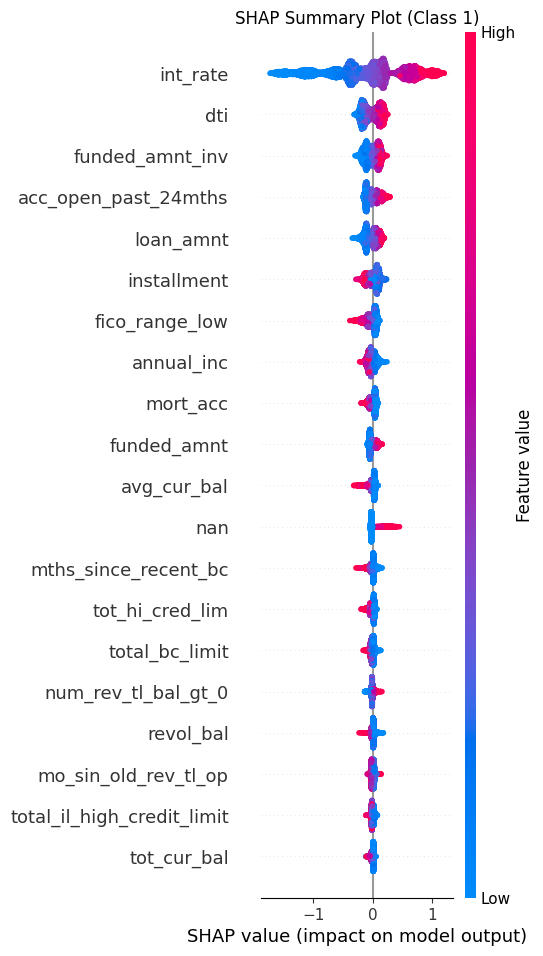

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

class xai():
  def __init__(self, model, x_test, feature_names):
    self.model = model
    self.x_test = x_test
    self.feature_names = feature_names
    self.explainer = shap.TreeExplainer(self.model)
    # Store the full list of shap values for all classes for summary plot
    # self.all_shap_values will be a list of arrays, e.g., [shap_values_class0_all_instances, shap_values_class1_all_instances]
    self.all_shap_values = self.explainer.shap_values(self.x_test)

    # The expected_value for binary classification can be a scalar or a list.
    # We need the base value for the positive class (index 1 if it's a list, or the scalar itself).
    if isinstance(self.explainer.expected_value, list):
        self.expected_value_for_waterfall = self.explainer.expected_value[1]
    else:
        self.expected_value_for_waterfall = self.explainer.expected_value

  def plot_waterfall(self, instance_index=0):
    # Reshape the single instance to be 2-dimensional (1 row, -1 columns)
    single_instance_data = self.x_test[instance_index].reshape(1, -1)
    # Get SHAP values for the specific instance for both classes
    shap_values_for_single_instance = self.explainer.shap_values(single_instance_data)
    # Select SHAP values for the positive class (class 1) for this instance
    shap_values_class1_for_instance = shap_values_for_single_instance[0]

    # Create a shap.Explanation object for the specific instance and class
    explanation = shap.Explanation(
        values=shap_values_class1_for_instance,
        base_values=self.expected_value_for_waterfall,
        data=single_instance_data[0], # Pass the 1D data for Explanation object
        feature_names=self.feature_names
    )
    # Pass the Explanation object to waterfall_plot
    shap.waterfall_plot(explanation, show=False)
    plt.title(f'SHAP Waterfall Plot for Instance {instance_index}')

  def plot_summary(self, ax=None):
    # Pass the full list of SHAP values to summary_plot, and specify class_inds=1 for binary classification
    # self.all_shap_values is already a list of arrays, which summary_plot expects for multi-output
    shap.summary_plot(self.all_shap_values, self.x_test, feature_names=self.feature_names, show=False, class_inds=1)
    plt.title('SHAP Summary Plot (Class 1)')

all_feature_names = numerical_cols + list(tfidf.get_feature_names_out())
plt.figure(figsize=(12, 6))
explainable = xai(trained_tfidf, x_test_tfidf, all_feature_names)
plt.subplot(1,2,1)
sum_plot=explainable.plot_summary()
plt.savefig('/content/drive/MyDrive/gg/sum_plot')



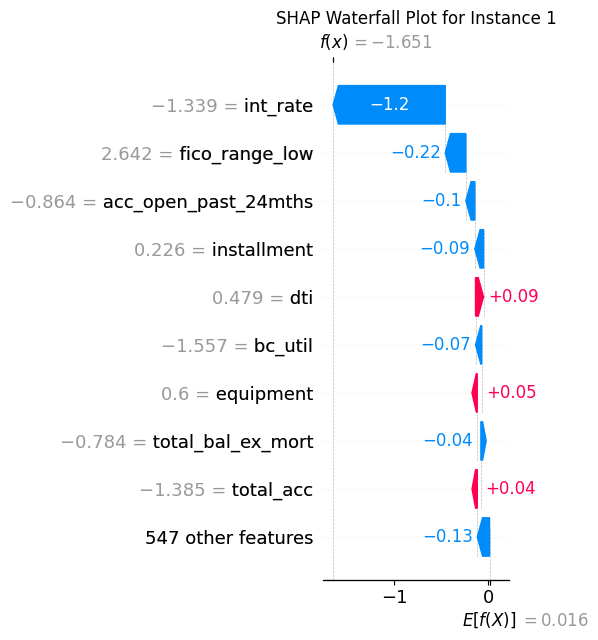

In [ ]:
plt.subplot(1,2,2)
wat_plot=explainable.plot_waterfall(instance_index=1)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/gg/wat_plot')

plt.show()


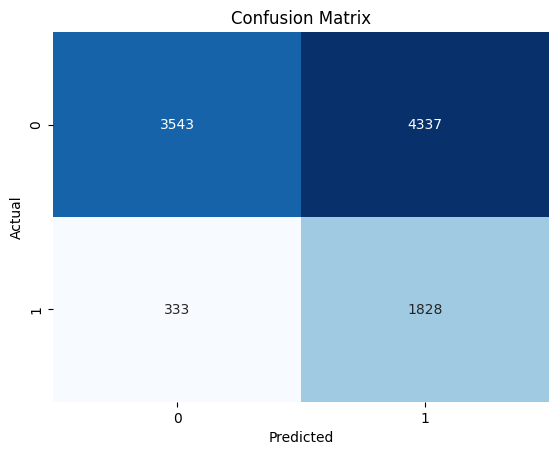

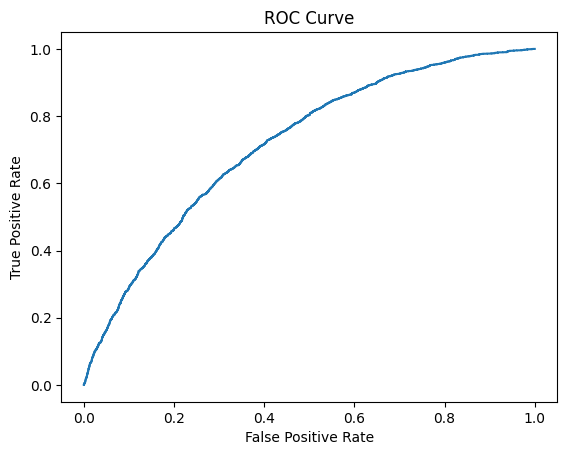

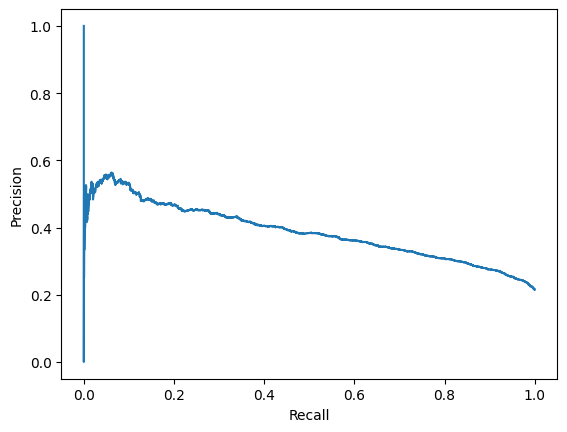

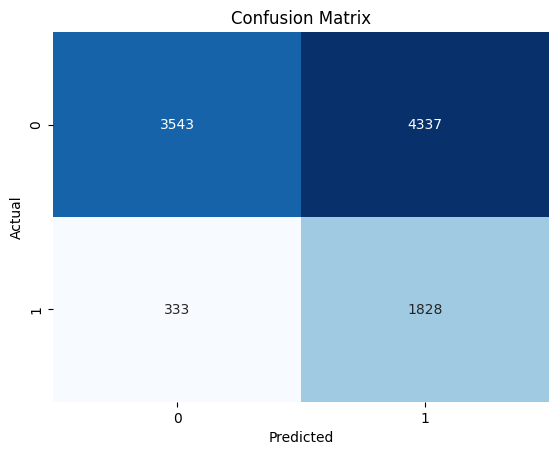

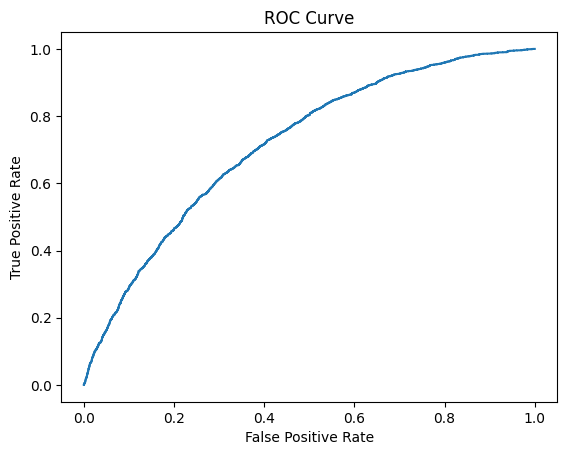

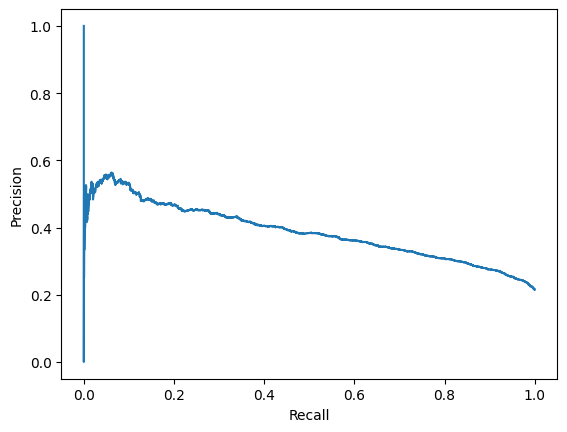

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix as sk_confusion_matrix, roc_curve as sk_roc_curve, precision_recall_curve as sk_precision_recall_curve

def plot_confusion_matrix(y_test, pred):
  cm = sk_confusion_matrix(y_test, pred)
  plt.figure()
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.title('Confusion Matrix')
  plt.savefig('/content/drive/MyDrive/gg/cm_plot.png', dpi=150, bbox_inches='tight')

  plt.show()


def plot_roc_auc_curve(pred_proba, y_test):
  fpr, tpr, thresholds = sk_roc_curve(y_test, pred_proba)
  plt.figure()
  plt.plot(fpr, tpr, label='ROC curve')
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title('ROC Curve')
  plt.savefig('/content/drive/MyDrive/gg/roc_plot.png', dpi=150, bbox_inches='tight')
  plt.show()



def plot_pr_curve(pred_proba, y_test):
  precision, recall, thresholds = sk_precision_recall_curve(y_test, pred_proba)
  plt.figure()
  plt.plot(recall, precision, label='PR curve')
  plt.xlabel('Recall')
  plt.ylabel('Precision')
  plt.savefig('/content/drive/MyDrive/gg/pr_plot.png', dpi=150, bbox_inches='tight')

  plt.show()



pred_proba = trained_tfidf.predict_proba(x_test_tfidf)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, pred_proba)
scores = precision[:-1] * recall[:-1]
threshold = thresholds[np.argmax(scores)]
pred = (pred_proba >= threshold).astype(int)


cm_plot = plot_confusion_matrix(y_test, pred)
roc_plot = plot_roc_auc_curve(pred_proba, y_test)
pr_plot = plot_pr_curve(pred_proba, y_test)





In [ ]:
import json
import os

# --- IMPORTANT: You MUST replace "your_actual_notebook_name.ipynb" with the exact filename of THIS Colab notebook. ---
# You can find the filename at the top of the browser tab or in the Colab file menu.
# Example: if your notebook is named 'MyProjectNotebook.ipynb', set notebook_path = "MyProjectNotebook.ipynb"
notebook_path = "/content/drive/MyDrive/Colab Notebooks/Copy of gg"


# Check if the file exists before attempting to open it
if not os.path.exists(notebook_path):
    print(f"Error: The notebook file '{notebook_path}' was not found. Please ensure the 'notebook_path' variable is set to the correct filename of this notebook.")
else:
    with open(notebook_path, "r", encoding="utf-8") as f:
        nb = json.load(f)

    # Strip the broken widget metadata
    if "widgets" in nb.get("metadata", {}):
        del nb["metadata"]["widgets"]

    with open(notebook_path, "w", encoding="utf-8") as f:
        json.dump(nb, f, indent=1)

    print("Done — widget metadata removed.")

Done — widget metadata removed.


In [ ]:
from google.colab import drive
drive.flush_and_unmount()
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive
